# Candidate-pool size ablation across all datasets

Pulls the latest `<dataset>_candidate_size` run for **every** dataset from the `ablation` wandb project, recovers the per-`(dataset, candidate_size, model, seed)` rows from each run's history, and plots deltaprop across candidate-pool sizes for every dataset as its own subplot in a shared figure.

Runs are named `<dataset>_candidate_size_<timestamp>`, so for each dataset prefix we keep only the most recently created run. Each `wandb.log(row)` call became a separate history step, so we read the full history with `scan_history()`.

Metric per dataset: `PK` and `SINGLE_TARGET_TBA` are reported with `test_roc_auc`; every other dataset with `test_average_precision`. chemprop baselines are excluded.

In [ ]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_SUFFIX = "candidate_size"  # study tag baked into every run name as '<dataset>_candidate_size'

# PK and SINGLE_TARGET_TBA are reported with ROC-AUC; every other dataset with average precision.
ROC_AUC_DATASETS = {"PK", "SINGLE_TARGET_TBA"}


def metric_for(dataset: str) -> str:
    return "test_roc_auc" if dataset in ROC_AUC_DATASETS else "test_average_precision"


api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")

# Each candidate_size study logs one run named '<dataset>_candidate_size_<timestamp>'.
# Group by the dataset prefix and keep only the most recently created run per dataset.
latest = {}
for r in runs:
    if RUN_SUFFIX not in r.name:
        continue
    prefix = r.name.split(f"_{RUN_SUFFIX}")[0]
    if prefix not in latest or r.created_at > latest[prefix].created_at:
        latest[prefix] = r

for prefix, r in sorted(latest.items()):
    print(f"{prefix:18s} {r.name:46s} {r.id}  {r.created_at}")

db_hepg2           db_hepg2_candidate_size_20260621_211743        k317y3cb  2026-06-21T21:17:45Z
db_malaria         db_malaria_candidate_size_20260621_225217      m0nmqusz  2026-06-21T22:52:18Z
dual_target_tba    dual_target_tba_candidate_size_20260621_212007 jrpswjhm  2026-06-21T21:20:08Z
pk                 pk_candidate_size_20260621_230348              6b28jz9f  2026-06-21T23:03:49Z
single_target_tba  single_target_tba_candidate_size_20260621_211943 8cpbtqbp  2026-06-21T21:19:44Z


In [ ]:
# Full, unsampled history per run -> one row per (dataset, candidate_size, model, seed).
frames = [pd.DataFrame(r.scan_history()) for r in latest.values()]
hist = pd.concat(frames, ignore_index=True)

# deltaprop only: chemprop baselines are excluded per request, and chemprop is
# invariant to candidate_size (it appears once per seed with candidate_size = NaN anyway).
delta = hist[hist["model"] == "deltaprop"].copy()
delta = delta[
    ["dataset", "candidate_size", "seed", "n_train", "test_roc_auc", "test_average_precision"]
].sort_values(["dataset", "candidate_size", "seed"])
print("datasets:", sorted(delta["dataset"].unique()))
delta.head()

datasets: ['DB_HEPG2', 'DB_MALARIA', 'DUAL_TARGET_TBA', 'PK', 'SINGLE_TARGET_TBA']


,dataset,candidate_size,seed,n_train,val_roc_auc,val_average_precision
1,DB_HEPG2,2.0,42,1519,0.752688,0.111470
8,DB_HEPG2,2.0,53,1516,0.782432,0.290569
15,DB_HEPG2,2.0,64,1518,0.778378,0.140110
22,DB_HEPG2,2.0,75,1516,0.864865,0.116958
29,DB_HEPG2,2.0,86,1518,0.874324,0.339201


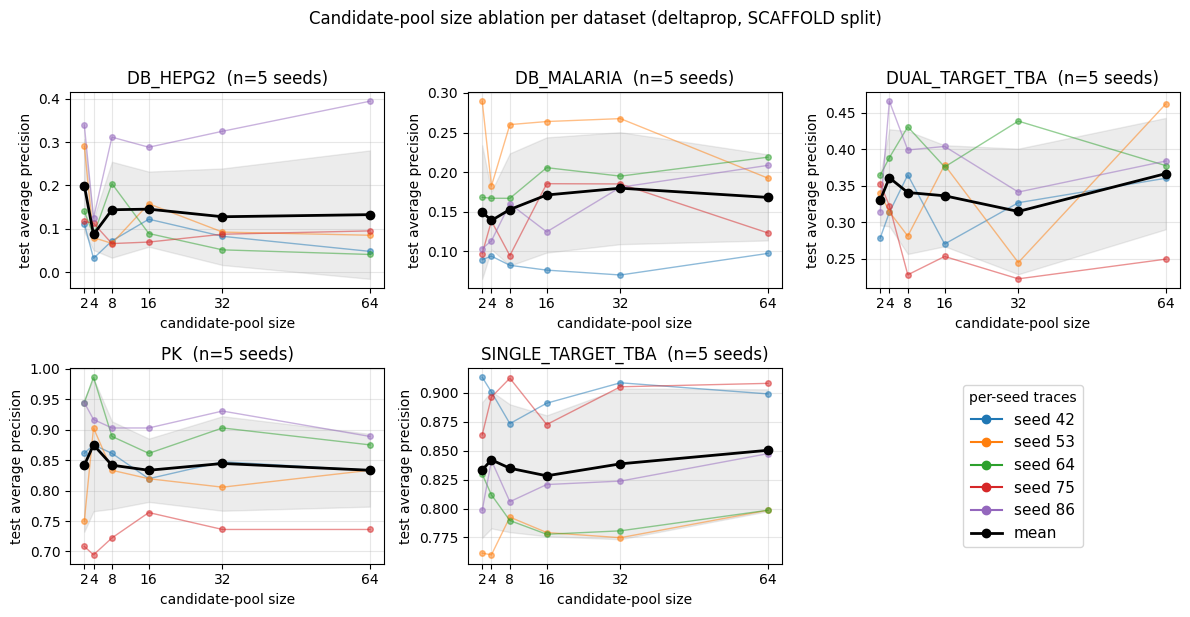

In [6]:
import math
from matplotlib.lines import Line2D

# One subplot per dataset in a shared grid. Each subplot draws one light, colored line
# per seed connecting that seed's points across the sweep, with the across-seed mean as
# a bold black line and a +/- std band on top. Each subplot uses that dataset's
# designated metric (ROC-AUC for PK / SINGLE_TARGET_TBA, average precision otherwise).
datasets = sorted(delta["dataset"].unique())
seeds = sorted(delta["seed"].unique())
xticks = sorted(delta["candidate_size"].dropna().unique())

# Consistent color per seed across every subplot.
seed_colors = {s: plt.cm.tab10(i % 10) for i, s in enumerate(seeds)}

ncols = 3
nrows = math.ceil(len(datasets) / ncols)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False
)
axes_flat = axes.ravel()

for ax, dataset in zip(axes_flat, datasets):
    g = delta[delta["dataset"] == dataset]
    metric = metric_for(dataset)
    metric_label = (
        "test ROC-AUC" if metric == "test_roc_auc" else "test average precision"
    )

    # Per-seed traces: connect each seed's points across the sweep, light alpha.
    for seed, sg in g.groupby("seed"):
        sg = sg.sort_values("candidate_size")
        ax.plot(
            sg["candidate_size"],
            sg[metric],
            marker="o",
            markersize=4,
            linewidth=1,
            color=seed_colors[seed],
            alpha=0.5,
            zorder=2,
        )

    # Across-seed mean + std band on top.
    agg = (
        g.groupby("candidate_size")[metric]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
        .sort_values("candidate_size")
    )
    ax.plot(
        agg["candidate_size"], agg["mean"], marker="o", color="black", linewidth=2, zorder=5
    )
    ax.fill_between(
        agg["candidate_size"],
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        color="gray",
        alpha=0.15,
        zorder=1,
    )

    ax.set_xticks(xticks)
    ax.set_xlabel("candidate-pool size")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{dataset}  (n={g['seed'].nunique()} seeds)")
    ax.grid(True, alpha=0.3)

# Shared seed legend; drop it into the first leftover axis when the grid has one.
handles = [
    Line2D([0], [0], color=seed_colors[s], marker="o", label=f"seed {s}") for s in seeds
]
handles.append(Line2D([0], [0], color="black", marker="o", linewidth=2, label="mean"))

leftover = axes_flat[len(datasets):]
for ax in leftover:
    ax.set_visible(False)
if len(leftover):
    legend_ax = leftover[0]
    legend_ax.set_visible(True)
    legend_ax.axis("off")
    legend_ax.legend(handles=handles, loc="center", fontsize=11, title="per-seed traces")
else:
    fig.legend(handles=handles, loc="upper right", ncol=len(handles), fontsize=8)

fig.suptitle(
    "Candidate-pool size ablation per dataset (deltaprop, SCAFFOLD split)",
    # "thin colored lines = per-seed traces; bold black = mean; band = +/- 1 std",
    y=1.02,
)
fig.tight_layout()
# fig.savefig("all_datasets_candidate_size_ablation.png", dpi=150, bbox_inches="tight")
plt.show()